# cv-homography-degradation — main_colab

Single Colab notebook for:
- cloning/updating the repo
- installing requirements
- downloading HPatches into the current Colab session
- writing a Colab runtime config
- sanity-checking the dataset loader
- running ORB, XFeat, or Proposed experiments
- summarizing and inspecting outputs

This notebook uses **local session storage** for HPatches, not Google Drive.

In [1]:
# --- User settings ---
REPO_URL = "https://github.com/khalayli/cv-homography-degradation"
REPO_DIR = "/content/cv-homography-degradation"

DATASET_SAVE_DIR = "/content/data/hpatches"
DATASET_NAME = "hpatches-sequences-release"
HPATCHES_URL = "https://huggingface.co/datasets/vbalnt/hpatches/resolve/main/hpatches-sequences-release.zip"

FORCE_REDOWNLOAD = False
FORCE_UNZIP = False

LIMIT_PAIRS = 10          # set to None for a fuller run , 10 for quick test
MATCHER_NAME = "orb"      # choose: "orb", "xfeat", or "proposed"

RUNTIME_CONFIG_PATH = "configs/colab_runtime.yaml"

print(f"[settings] REPO_URL={REPO_URL}")
print(f"[settings] REPO_DIR={REPO_DIR}")
print(f"[settings] DATASET_SAVE_DIR={DATASET_SAVE_DIR}")
print(f"[settings] DATASET_NAME={DATASET_NAME}")
print(f"[settings] LIMIT_PAIRS={LIMIT_PAIRS}")
print(f"[settings] MATCHER_NAME={MATCHER_NAME}")
print(f"[settings] RUNTIME_CONFIG_PATH={RUNTIME_CONFIG_PATH}")

[settings] REPO_URL=https://github.com/khalayli/cv-homography-degradation
[settings] REPO_DIR=/content/cv-homography-degradation
[settings] DATASET_SAVE_DIR=/content/data/hpatches
[settings] DATASET_NAME=hpatches-sequences-release
[settings] LIMIT_PAIRS=10
[settings] MATCHER_NAME=orb
[settings] RUNTIME_CONFIG_PATH=configs/colab_runtime.yaml


In [2]:
# --- Clone or update the repo, then install requirements ---
import os
import subprocess
import sys


def run_cmd(cmd, cwd=None):
    print(f"[run_cmd] cwd={cwd} cmd={' '.join(cmd)}")
    completed = subprocess.run(cmd, cwd=cwd, check=True, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    return completed


if not os.path.exists(REPO_DIR):
    print("[repo] Repo not found locally. Cloning now...")
    run_cmd(["git", "clone", REPO_URL, REPO_DIR])
else:
    print("[repo] Repo already exists. Pulling latest changes...")
    run_cmd(["git", "pull"], cwd=REPO_DIR)

print("[repo] Installing requirements...")
run_cmd([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], cwd=REPO_DIR)

os.chdir(REPO_DIR)
print(f"[repo] Working directory set to: {os.getcwd()}")

[repo] Repo not found locally. Cloning now...
[run_cmd] cwd=None cmd=git clone https://github.com/khalayli/cv-homography-degradation /content/cv-homography-degradation
Cloning into '/content/cv-homography-degradation'...

[repo] Installing requirements...
[run_cmd] cwd=/content/cv-homography-degradation cmd=/usr/bin/python3 -m pip install -r requirements.txt

[repo] Working directory set to: /content/cv-homography-degradation


In [3]:
# ---- Xfeat pretrained weights loading
import os
from pathlib import Path
import subprocess

weights_dir = Path(REPO_DIR) / "weights"
weights_dir.mkdir(parents=True, exist_ok=True)

xfeat_weights = weights_dir / "xfeat.pt"
if not xfeat_weights.exists():
    print(f"[weights] Downloading XFeat weights to {xfeat_weights}")
    subprocess.run(
        [
            "wget",
            "-O",
            str(xfeat_weights),
            "https://github.com/verlab/accelerated_features/raw/main/weights/xfeat.pt",
        ],
        check=True,
    )
else:
    print(f"[weights] Already exists: {xfeat_weights}")



[weights] Downloading XFeat weights to /content/cv-homography-degradation/weights/xfeat.pt


In [4]:
# --- Ensure HPatches exists in the current Colab session ---
import os
import subprocess
from pathlib import Path


def _looks_like_hpatches_root(extracted_path):
    print(f"[_looks_like_hpatches_root] Checking extracted_path={extracted_path}")
    root = Path(extracted_path)

    if not root.exists() or not root.is_dir():
        print("[_looks_like_hpatches_root] Root does not exist or is not a directory.")
        return False

    scene_dirs = [p for p in root.iterdir() if p.is_dir()]
    print(f"[_looks_like_hpatches_root] Found {len(scene_dirs)} scene directories.")

    if len(scene_dirs) == 0:
        print("[_looks_like_hpatches_root] No scene directories found.")
        return False

    sample_scene = scene_dirs[0]
    print(f"[_looks_like_hpatches_root] Sample scene={sample_scene}")

    sample_img_1 = sample_scene / "1.ppm"
    sample_img_2 = sample_scene / "2.ppm"
    sample_h = sample_scene / "H_1_2"

    ok = sample_img_1.exists() and sample_img_2.exists() and sample_h.exists()
    print(
        f"[_looks_like_hpatches_root] "
        f"1.ppm={sample_img_1.exists()}, "
        f"2.ppm={sample_img_2.exists()}, "
        f"H_1_2={sample_h.exists()}"
    )
    print(f"[_looks_like_hpatches_root] ok={ok}")
    return ok


def ensure_hpatches_local(
    save_dir="/content/data/hpatches",
    dataset_name="hpatches-sequences-release",
    url="https://huggingface.co/datasets/vbalnt/hpatches/resolve/main/hpatches-sequences-release.zip",
    force_redownload=False,
    force_unzip=False,
):
    print("[ensure_hpatches_local] Starting dataset check...")
    print(f"[ensure_hpatches_local] save_dir={save_dir}")
    os.makedirs(save_dir, exist_ok=True)

    zip_path = os.path.join(save_dir, f"{dataset_name}.zip")
    extracted_path = os.path.join(save_dir, dataset_name)

    print(f"[ensure_hpatches_local] zip_path={zip_path}")
    print(f"[ensure_hpatches_local] extracted_path={extracted_path}")

    if force_redownload:
        print("[ensure_hpatches_local] force_redownload=True")
        if os.path.exists(zip_path):
            os.remove(zip_path)
            print("[ensure_hpatches_local] Existing zip removed.")
        if os.path.exists(extracted_path):
            subprocess.run(["rm", "-rf", extracted_path], check=True)
            print("[ensure_hpatches_local] Existing extracted folder removed.")

    if not force_unzip and _looks_like_hpatches_root(extracted_path):
        print("[ensure_hpatches_local] Valid extracted dataset already exists. Skipping download/unzip.")
        return extracted_path

    if not os.path.exists(zip_path):
        print("[ensure_hpatches_local] Zip not found. Downloading...")
        subprocess.run(["wget", "-c", url, "-O", zip_path], check=True)
        print("[ensure_hpatches_local] Download complete.")
    else:
        print("[ensure_hpatches_local] Zip already exists in current session.")

    if force_unzip and os.path.exists(extracted_path):
        print("[ensure_hpatches_local] force_unzip=True, removing existing extracted folder.")
        subprocess.run(["rm", "-rf", extracted_path], check=True)
        print("[ensure_hpatches_local] Existing extracted folder removed for fresh unzip.")

    if not _looks_like_hpatches_root(extracted_path):
        print("[ensure_hpatches_local] Valid extracted dataset not found. Unzipping dataset...")
        subprocess.run(["unzip", "-q", "-o", zip_path, "-d", save_dir], check=True)
        print("[ensure_hpatches_local] Unzip complete.")
    else:
        print("[ensure_hpatches_local] Extracted folder already valid. Skipping unzip.")

    if not _looks_like_hpatches_root(extracted_path):
        raise RuntimeError(
            f"[ensure_hpatches_local] Dataset extraction completed, but structure still looks invalid: {extracted_path}"
        )

    print("[ensure_hpatches_local] Final directory listing:")
    subprocess.run(["ls", "-lah", save_dir], check=True)

    print(f"[ensure_hpatches_local] Dataset ready at: {extracted_path}")
    return extracted_path


dataset_root = ensure_hpatches_local(
    save_dir=DATASET_SAVE_DIR,
    dataset_name=DATASET_NAME,
    url=HPATCHES_URL,
    force_redownload=FORCE_REDOWNLOAD,
    force_unzip=FORCE_UNZIP,
)
print(f"[main] dataset_root={dataset_root}")

[ensure_hpatches_local] Starting dataset check...
[ensure_hpatches_local] save_dir=/content/data/hpatches
[ensure_hpatches_local] zip_path=/content/data/hpatches/hpatches-sequences-release.zip
[ensure_hpatches_local] extracted_path=/content/data/hpatches/hpatches-sequences-release
[_looks_like_hpatches_root] Checking extracted_path=/content/data/hpatches/hpatches-sequences-release
[_looks_like_hpatches_root] Root does not exist or is not a directory.
[ensure_hpatches_local] Zip not found. Downloading...
[ensure_hpatches_local] Download complete.
[_looks_like_hpatches_root] Checking extracted_path=/content/data/hpatches/hpatches-sequences-release
[_looks_like_hpatches_root] Root does not exist or is not a directory.
[ensure_hpatches_local] Valid extracted dataset not found. Unzipping dataset...
[ensure_hpatches_local] Unzip complete.
[_looks_like_hpatches_root] Checking extracted_path=/content/data/hpatches/hpatches-sequences-release
[_looks_like_hpatches_root] Found 116 scene directori

In [5]:
# --- Add repo to Python path and write a Colab-specific runtime config ---
import os
import sys
from pathlib import Path
import yaml

repo_path = Path(REPO_DIR).resolve()
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))
    print(f"[pythonpath] Added repo path: {repo_path}")
else:
    print(f"[pythonpath] Repo path already present: {repo_path}")

base_cfg_path = repo_path / "configs" / "default.yaml"
runtime_cfg_path = repo_path / RUNTIME_CONFIG_PATH
print(f"[config] base_cfg_path={base_cfg_path}")
print(f"[config] runtime_cfg_path={runtime_cfg_path}")

with open(base_cfg_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg["dataset"]["hpatches_root"] = dataset_root
cfg["run"]["out_dir"] = "results/colab_run"
cfg["run"]["name"] = f"colab_{MATCHER_NAME}"

cfg["method"]["name"] = MATCHER_NAME

if MATCHER_NAME in ["xfeat", "proposed"]:
    print("[xfeat] Enforcing pretrained weights requirement")

    if "xfeat" not in cfg["method"]:
        cfg["method"]["xfeat"] = {}

    xfeat_weights_path = repo_path / "weights" / "xfeat.pt"
    cfg["method"]["xfeat"]["weights_path"] = str(xfeat_weights_path)

    print(f"[xfeat] Expected weights path: {xfeat_weights_path}")
    print(f"[xfeat] Config weights_path: {cfg['method']['xfeat']['weights_path']}")

    if cfg["method"]["xfeat"]["weights_path"] in [None, "", "null"]:
        raise ValueError(
            "[xfeat] weights_path is null/empty. Refusing to run XFeat without pretrained weights."
        )

    if not xfeat_weights_path.exists():
        raise FileNotFoundError(
            f"[xfeat] Missing weights file: {xfeat_weights_path}. "
            "Download xfeat.pt into repo_root/weights/ before running."
        )

    print("[xfeat] Pretrained weights found. Proceeding.")

if MATCHER_NAME == "proposed":
    if "proposed" not in cfg["method"]:
        cfg["method"]["proposed"] = {}

    cfg["method"]["proposed"]["enabled"] = True
    cfg["method"]["proposed"].setdefault("adaptive_thresholds", True)
    cfg["method"]["proposed"].setdefault("fallback_enabled", True)
    cfg["method"]["proposed"].setdefault("primary_matcher", "xfeat")
    cfg["method"]["proposed"].setdefault("fallback_matcher", "orb")
    cfg["method"]["proposed"].setdefault("min_matches_before_fallback", 30)

runtime_cfg_path.parent.mkdir(parents=True, exist_ok=True)

with open(runtime_cfg_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print(f"[config] Wrote runtime config to: {runtime_cfg_path}")
print("[config] Runtime config contents:")
with open(runtime_cfg_path, "r", encoding="utf-8") as f:
    print(f.read())

[pythonpath] Added repo path: /content/cv-homography-degradation
[config] base_cfg_path=/content/cv-homography-degradation/configs/default.yaml
[config] runtime_cfg_path=/content/cv-homography-degradation/configs/colab_runtime.yaml
[config] Wrote runtime config to: /content/cv-homography-degradation/configs/colab_runtime.yaml
[config] Runtime config contents:
run:
  name: colab_orb
  seed: 123
  out_dir: results/colab_run
dataset:
  name: hpatches
  hpatches_root: /content/data/hpatches/hpatches-sequences-release
  pairs_per_scene: 5
corruptions:
  enabled: true
  mode: single
  include_clean: true
  apply_to: target
  types:
  - gaussian_blur
  - motion_blur
  - gaussian_noise
  - jpeg_compression
  - brightness
  - contrast
  severities:
  - 0
  - 1
  - 2
  - 3
  - 4
method:
  name: orb
  orb:
    nfeatures: 2000
    scaleFactor: 1.2
    nlevels: 8
    fastThreshold: 20
    ratio_test: 0.8
  xfeat:
    device: cpu
    top_k: 1024
    weights_path: null
    score_threshold: null
  pro

In [6]:
# --- Sanity check the HPatches loader ---
from src.data.hpatches import HPatchesDataset

print("[sanity] Building HPatchesDataset...")
dataset = HPatchesDataset(root=dataset_root, pairs_per_scene=5)

if hasattr(dataset, "describe"):
    summary = dataset.describe()
    print(f"[sanity] summary={summary}")
elif hasattr(dataset, "summarize"):
    summary = dataset.summarize()
    print(f"[sanity] summary={summary}")
else:
    print("[sanity] Dataset has no describe/summarize method")

if hasattr(dataset, "pairs"):
    print(f"[sanity] num_pairs={len(dataset.pairs)}")
elif hasattr(dataset, "samples"):
    print(f"[sanity] num_pairs={len(dataset.samples)}")

example = dataset[0]

if hasattr(example, "pair"):
    print(f"[sanity] scene_name={example.pair.scene_name}")
    print(f"[sanity] split={example.pair.split}")
    print(f"[sanity] image0_shape={example.image0.shape}")
    print(f"[sanity] image1_shape={example.image1.shape}")
    print(f"[sanity] H_gt_shape={example.homography_gt.shape}")
else:
    print(f"[sanity] scene_name={example.get('scene_name', example.get('scene'))}")
    print(f"[sanity] split={example.get('split')}")
    print(f"[sanity] image0_shape={example.get('image0', example.get('image_src')).shape}")
    print(f"[sanity] image1_shape={example.get('image1', example.get('image_tgt')).shape}")
    print(f"[sanity] H_gt_shape={example.get('homography_gt', example.get('H_gt')).shape}")

[sanity] Building HPatchesDataset...
[HPatchesDataset.__init__] Initializing HPatches dataset...
[HPatchesDataset.__init__] root=/content/data/hpatches/hpatches-sequences-release
[HPatchesDataset.__init__] pairs_per_scene=5
[HPatchesDataset._build_index] Building dataset index...
[HPatchesDataset._build_index] Found 116 scene directories.
[HPatchesDataset._build_index] Total pairs indexed: 580
[HPatchesDataset.describe] Summarizing dataset...
[HPatchesDataset.describe] summary={'root': '/content/data/hpatches/hpatches-sequences-release', 'num_pairs': 580, 'num_scenes': 116, 'pairs_per_scene': 5, 'split_counts': {'illumination': 285, 'viewpoint': 295}}
[sanity] summary={'root': '/content/data/hpatches/hpatches-sequences-release', 'num_pairs': 580, 'num_scenes': 116, 'pairs_per_scene': 5, 'split_counts': {'illumination': 285, 'viewpoint': 295}}
[sanity] num_pairs=580
[HPatchesDataset.__getitem__] Loading pair idx=0, scene=i_ajuntament
[HPatchesDataset._read_image] Reading image: /content

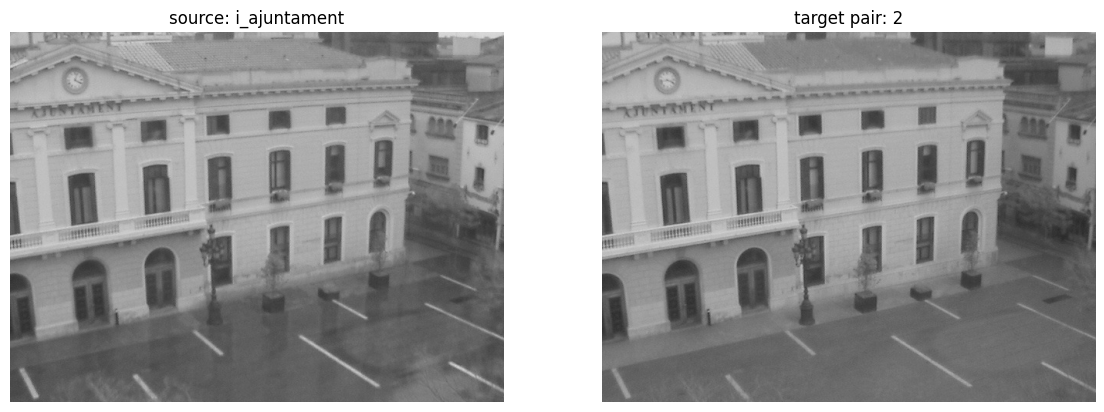

In [7]:
# --- Visualize one pair quickly ---
import matplotlib.pyplot as plt
import cv2

if hasattr(example, "pair"):
    img0 = example.image0
    img1 = example.image1
    title_scene = example.pair.scene_name
    title_pair = example.pair.pair_index
else:
    img0 = example.get("image0", example.get("image_src"))
    img1 = example.get("image1", example.get("image_tgt"))
    title_scene = example.get("scene_name", example.get("scene"))
    title_pair = example.get("pair_index", example.get("pair"))

img0_rgb = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(img0_rgb)
plt.title(f"source: {title_scene}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img1_rgb)
plt.title(f"target pair: {title_pair}")
plt.axis("off")
plt.show()

In [27]:
from tqdm.auto import tqdm
import subprocess
import sys

# Prepare command
cmd = [sys.executable, "scripts/run_experiment.py", "--config", RUNTIME_CONFIG_PATH]
if LIMIT_PAIRS is not None:
    cmd += ["--limit-pairs", str(LIMIT_PAIRS)]
    total_steps = LIMIT_PAIRS
else:
    total_steps = 580

print(f"[experiment] Starting: {' '.join(cmd)}")

pbar = tqdm(total=total_steps, desc="Processing Pairs")

# Run and parse output for progress WITHOUT printing lines
with subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1) as proc:
    for line in proc.stdout:
        # Increment progress bar whenever a new pair starts
        if "Processing pair_idx=" in line:
            pbar.update(1)

pbar.close()

if proc.returncode != 0:
    print(f"[experiment] Error: Process exited with code {proc.returncode}")
else:
    print("[experiment] Completed successfully.")

[experiment] Starting: /usr/bin/python3 scripts/run_experiment.py --config configs/colab_runtime.yaml --limit-pairs 10


Processing Pairs:   0%|          | 0/10 [00:00<?, ?it/s]

[experiment] Completed successfully.


In [28]:
# --- Summarize results ---
import subprocess
import sys

metrics_csv = "results/colab_run/metrics.csv"
cmd = [sys.executable, "scripts/summarize_results.py", "--input", metrics_csv]
print(f"[summary] cmd={' '.join(cmd)}")
subprocess.run(cmd, check=True)
print("[summary] Done")

[summary] cmd=/usr/bin/python3 scripts/summarize_results.py --input results/colab_run/metrics.csv
[summary] Done


In [29]:
# --- Inspect outputs ---
import os
import pandas as pd
from IPython.display import display

metrics_csv = "results/colab_run/metrics.csv"
summary_json = "results/colab_run/summary.json"
summary_csv = "results/colab_run/summary.csv"
summary_aggregated_json = "results/colab_run/summary_aggregated.json"

for path in [metrics_csv, summary_json, summary_csv, summary_aggregated_json]:
    print(f"[outputs] {path} exists={os.path.exists(path)}")

metrics_df = pd.read_csv(metrics_csv)
print(f"[outputs] metrics_df_shape={metrics_df.shape}")
display(metrics_df.head())

if os.path.exists(summary_csv):
    summary_df = pd.read_csv(summary_csv)
    print(f"[outputs] summary_df_shape={summary_df.shape}")
    display(summary_df.head())

[outputs] results/colab_run/metrics.csv exists=True
[outputs] results/colab_run/summary.json exists=True
[outputs] results/colab_run/summary.csv exists=True
[outputs] results/colab_run/summary_aggregated.json exists=True
[outputs] metrics_df_shape=(250, 21)


,scene_name,split,pair_index,matcher,corruption,severity,runtime_s,num_matches,num_inliers,reproj_rmse,...,mean_corner_error,success@1,success@3,success@5,success@10,backend_used,fallback_used,used_reproj_threshold,used_confidence,used_max_iters
0,i_ajuntament,illumination,2,orb,none,0,0.133662,803,731,NaN,...,0.238998,1,1,1,1,NaN,0,3.0,0.999,5000
1,i_ajuntament,illumination,3,orb,none,0,0.070593,66,35,NaN,...,1.700842,0,1,1,1,NaN,0,3.0,0.999,5000
2,i_ajuntament,illumination,4,orb,none,0,0.065682,16,7,NaN,...,71.278958,0,0,0,0,NaN,0,3.0,0.999,5000
3,i_ajuntament,illumination,5,orb,none,0,0.134854,30,10,NaN,...,150.734886,0,0,0,0,NaN,0,3.0,0.999,5000
4,i_ajuntament,illumination,6,orb,none,0,0.120747,26,8,NaN,...,3994.002110,0,0,0,0,NaN,0,3.0,0.999,5000


[outputs] summary_df_shape=(25, 15)


,matcher,corruption,severity,num_pairs,mean_runtime_s,homography_return_rate,mean_corner_error_finite,median_corner_error,num_finite_corner_errors,success@1,success@3,success@5,success@10,success_rate_3px,success_rate_5px
0,orb,brightness,1,10,0.088951,1.0,528.294227,31.578124,10,0.1,0.3,0.4,0.4,0.3,0.4
1,orb,brightness,2,10,0.089783,1.0,269.844624,10.656287,10,0.2,0.3,0.4,0.5,0.3,0.4
2,orb,brightness,3,10,0.090108,1.0,479.869699,15.946027,10,0.2,0.3,0.3,0.5,0.3,0.3
3,orb,brightness,4,10,0.090241,1.0,191.169219,12.575906,10,0.2,0.4,0.4,0.5,0.4,0.4
4,orb,contrast,1,10,0.097873,1.0,688.662780,20.057339,10,0.2,0.3,0.3,0.3,0.3,0.3


In [30]:
# --- Optional: switch matcher and rerun ---
# Set MATCHER_NAME in the settings cell to one of:
# - "orb"
# - "xfeat"
# - "proposed"
#
# Then rerun these cells:
# 1) the runtime-config cell
# 2) the experiment cell
# 3) the summary cell
# 4) the outputs cell
print("[note] Change MATCHER_NAME in the settings cell, then rerun config + experiment + summary + outputs.")

[note] Change MATCHER_NAME in the settings cell, then rerun config + experiment + summary + outputs.


In [31]:
from google.colab import files
import os

output_files = [
    "results/colab_run/metrics.csv",
    "results/colab_run/summary.json",
    "results/colab_run/summary.csv",
    "results/colab_run/summary_aggregated.json",
]

for file_path in output_files:
    if os.path.exists(file_path):
        print(f"Attempting to download {file_path}...")
        files.download(file_path)
    else:
        print(f"File not found: {file_path}")

print("If the files do not download automatically, please ensure your browser allows pop-ups and direct downloads from this page. If issues persist, consider using the Google Drive saving method provided in the previous steps.")


Attempting to download results/colab_run/metrics.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Attempting to download results/colab_run/summary.json...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Attempting to download results/colab_run/summary_aggregated.json...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

If the files do not download automatically, please ensure your browser allows pop-ups and direct downloads from this page. If issues persist, consider using the Google Drive saving method provided in the previous steps.


In [ ]:
# One-cell Pareto mini-benchmark for ORB / XFeat / Proposed on a tiny degraded HPatches stress subset.
# Paste this into your notebook and run it.
# It will:
# 1) find the repo root and HPatches root
# 2) copy xfeat.pt into weights/xfeat.pt
# 3) pick a tiny stress subset from HPatches
# 4) run ORB, XFeat, and Proposed on medium degradations
# 5) compute mean runtime per pair + macro degraded success@3 and success@5
# 6) save CSVs and one Pareto scatter plot

import os
import sys
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except Exception:
    yaml = None


# =========================
# USER OVERRIDES (optional)
# =========================
REPO_ROOT_OVERRIDE = None
HPATCHES_ROOT_OVERRIDE = None
XFEAT_WEIGHTS_OVERRIDE = None

# Small stress subset settings
NUM_STRESS_PAIRS = 10
STRESS_CORRUPTIONS = [
    ("gaussian_blur", 2),
    ("gaussian_blur", 4),
    ("gaussian_noise", 2),
    ("gaussian_noise", 4),
    ("jpeg_compression", 2),
    ("jpeg_compression", 4),
    ("brightness", 2),
    ("brightness", 4),
]
APPLY_TO = "target"
PAIR_INDEX_PREFERENCE = [2, 3, 4, 5, 6]

PLOT_SUCCESS_COL = "success@3"
OUTPUT_DIR_NAME = "results/pareto_stress_subset"

ORB_CFG = {
    "nfeatures": 2000,
    "scaleFactor": 1.2,
    "nlevels": 8,
    "fastThreshold": 20,
    "ratio_test": 0.75,
}

XFEAT_CFG = {
    "device": "cpu",
    "top_k": 1024,
    "weights_path": None,
    "score_threshold": None,
}

PROPOSED_CFG = {
    "enabled": True,
    "adaptive_thresholds": True,
    "fallback_enabled": True,

    # requested direction: ORB primary -> XFeat fallback
    "primary_matcher": "orb",
    "fallback_matcher": "xfeat",

    # shared degradation thresholds
    "blur_low_threshold": 60.0,
    "noise_high_threshold": 12.0,
    "contrast_low_threshold": 25.0,
    "jpeg_high_threshold": 2.0,
    "noise_flat_grad_threshold": 12.0,
    "brightness_low_threshold": 45.0,
    "brightness_high_threshold": 245.0,
    "dynamic_range_low_threshold": 55.0,

    # shared geometry override thresholds
    "reproj_threshold_nominal": 3.0,
    "reproj_threshold_hard": 4.0,
    "reproj_threshold_very_hard": 5.0,

    # shared cheap probe settings
    "probe_reproj_threshold": 3.0,
    "probe_confidence": 0.995,
    "probe_max_iters": 2000,
    "probe_min_area_ratio": 0.20,
    "probe_max_area_ratio": 4.00,
    "probe_margin_ratio": 0.25,

    # direction-aware fallback policy
    "direction_profiles": {
        "xfeat_to_orb": {
            "min_matches_before_fallback": 20,
            "max_adaptive_min_matches": 60,
            "min_matches_add_blur": 24,
            "min_matches_add_noise": 24,
            "min_matches_add_contrast": 12,
            "min_matches_add_jpeg": 12,
            "min_matches_add_dynamic_range": 16,
            "min_matches_add_brightness": 8,
            "fallback_min_spatial_coverage": 0.015,
            "fallback_min_score_mean": 0.20,
            "probe_min_inliers": 30,
            "probe_min_inlier_ratio": 0.40,
            "probe_min_inlier_coverage": 0.03,
        },
        "orb_to_xfeat": {
            "min_matches_before_fallback": 42,
            "max_adaptive_min_matches": 96,
            "min_matches_add_blur": 28,
            "min_matches_add_noise": 28,
            "min_matches_add_contrast": 16,
            "min_matches_add_jpeg": 12,
            "min_matches_add_dynamic_range": 20,
            "min_matches_add_brightness": 10,
            "fallback_min_spatial_coverage": 0.020,
            "fallback_min_score_mean": None,
            "probe_min_inliers": 18,
            "probe_min_inlier_ratio": 0.35,
            "probe_min_inlier_coverage": 0.02,
        },
    },
}

GEOM_CFG = {
    "reproj_threshold": 3.0,
    "confidence": 0.999,
    "max_iters": 5000,
}

EVAL_THRESHOLDS = [1, 3, 5, 10]


def print_header(msg: str) -> None:
    print("\n" + "=" * 100)
    print(msg)
    print("=" * 100)


def find_repo_root() -> Path:
    candidates = []
    if REPO_ROOT_OVERRIDE:
        candidates.append(Path(REPO_ROOT_OVERRIDE).expanduser())

    cwd = Path.cwd()
    candidates.extend([cwd, cwd / "Archive", cwd / "repo", cwd / "project", Path("/content"), Path("/content/Archive"), Path("/content/repo")])

    for root in candidates:
        try:
            root = root.resolve()
        except Exception:
            continue
        if (root / "src" / "matchers" / "proposed.py").exists() and (root / "src" / "matchers" / "xfeat.py").exists():
            return root

    for base in [cwd, Path("/content"), Path("/mnt/data")]:
        if not base.exists():
            continue
        for p in base.rglob("src/matchers/proposed.py"):
            root = p.parents[2]
            if (root / "src" / "matchers" / "xfeat.py").exists():
                return root

    raise FileNotFoundError("Could not locate repo root; set REPO_ROOT_OVERRIDE.")


def find_hpatches_root() -> Path:
    candidates = []
    if HPATCHES_ROOT_OVERRIDE:
        candidates.append(Path(HPATCHES_ROOT_OVERRIDE).expanduser())

    candidates.extend([
        Path("/content/data/hpatches/hpatches-sequences-release"),
        Path("/content/hpatches/hpatches-sequences-release"),
        Path("/content/hpatches-sequences-release"),
        Path("/kaggle/working/hpatches/hpatches-sequences-release"),
        Path("/mnt/data/hpatches/hpatches-sequences-release"),
    ])

    for root in candidates:
        if root.exists() and root.is_dir() and next(root.glob("*"), None) is not None:
            return root

    for base in [Path.cwd(), Path("/content"), Path("/mnt/data")]:
        if not base.exists():
            continue
        for p in base.rglob("hpatches-sequences-release"):
            if p.is_dir():
                return p

    raise FileNotFoundError("Could not locate HPatches root; set HPATCHES_ROOT_OVERRIDE.")


def find_xfeat_weights() -> Path:
    candidates = []
    if XFEAT_WEIGHTS_OVERRIDE:
        candidates.append(Path(XFEAT_WEIGHTS_OVERRIDE).expanduser())

    cwd = Path.cwd()
    candidates.extend([cwd / "xfeat.pt", cwd / "weights" / "xfeat.pt", Path("/content/xfeat.pt"), Path("/content/weights/xfeat.pt"), Path("/mnt/data/xfeat.pt")])

    for p in candidates:
        if p.exists() and p.is_file():
            return p

    for base in [cwd, Path("/content"), Path("/mnt/data")]:
        if not base.exists():
            continue
        for p in base.rglob("xfeat.pt"):
            if p.is_file():
                return p

    raise FileNotFoundError("Could not locate xfeat.pt; set XFEAT_WEIGHTS_OVERRIDE.")


def ensure_repo_on_path(repo_root: Path) -> None:
    repo_root_str = str(repo_root.resolve())
    if repo_root_str not in sys.path:
        sys.path.insert(0, repo_root_str)


def copy_weights_into_repo(repo_root: Path, src_weights_path: Path) -> Path:
    weights_dir = repo_root / "weights"
    weights_dir.mkdir(parents=True, exist_ok=True)
    dst = weights_dir / "xfeat.pt"
    shutil.copy2(src_weights_path, dst)
    return dst


def load_default_cfg(repo_root: Path) -> dict:
    cfg_path = repo_root / "configs" / "default.yaml"
    if cfg_path.exists() and yaml is not None:
        with open(cfg_path, "r", encoding="utf-8") as f:
            cfg = yaml.safe_load(f)
    else:
        cfg = {}

    cfg.setdefault("run", {})
    cfg.setdefault("dataset", {})
    cfg.setdefault("corruptions", {})
    cfg.setdefault("method", {})
    cfg.setdefault("geom", {})
    cfg.setdefault("eval", {})

    cfg["dataset"]["hpatches_root"] = None
    cfg["dataset"]["pairs_per_scene"] = 5
    cfg["geom"].update(GEOM_CFG)
    cfg["eval"]["corner_error_thresholds"] = EVAL_THRESHOLDS
    return cfg


def build_method_cfg(method_name: str, weights_path: Path) -> dict:
    method_cfg = {
        "name": method_name,
        "orb": dict(ORB_CFG),
        "xfeat": dict(XFEAT_CFG),
        "proposed": dict(PROPOSED_CFG),
    }
    method_cfg["xfeat"]["weights_path"] = str(weights_path)
    return method_cfg


def pick_stress_pairs(dataset) -> list:
    pairs = list(dataset.pairs)
    preferred_pair_index_order = {pair_idx: rank for rank, pair_idx in enumerate(PAIR_INDEX_PREFERENCE)}
    large_rank = 10**6

    illum = [p for p in pairs if getattr(p, "split", None) == "illumination"]
    view = [p for p in pairs if getattr(p, "split", None) == "viewpoint"]
    other = [p for p in pairs if getattr(p, "split", None) not in {"illumination", "viewpoint"}]

    def sort_key(p):
        return (preferred_pair_index_order.get(int(p.pair_index), large_rank), str(p.scene_name), int(p.pair_index))

    illum = sorted(illum, key=sort_key)
    view = sorted(view, key=sort_key)
    other = sorted(other, key=sort_key)

    selected, used_scenes = [], set()
    target_per_split = max(1, NUM_STRESS_PAIRS // 2)

    for bucket in [illum, view]:
        added_here = 0
        for p in bucket:
            if p.scene_name in used_scenes:
                continue
            selected.append(p)
            used_scenes.add(p.scene_name)
            added_here += 1
            if added_here >= target_per_split:
                break

    combined = illum + view + other
    for p in combined:
        if len(selected) >= min(NUM_STRESS_PAIRS, len(pairs)):
            break
        if p.scene_name in used_scenes:
            continue
        selected.append(p)
        used_scenes.add(p.scene_name)

    if len(selected) < min(NUM_STRESS_PAIRS, len(pairs)):
        for p in combined:
            if len(selected) >= min(NUM_STRESS_PAIRS, len(pairs)):
                break
            if any((q.scene_name == p.scene_name and q.pair_index == p.pair_index) for q in selected):
                continue
            selected.append(p)

    return selected


def build_subset_examples(dataset, selected_pairs: list) -> list:
    lookup = {(p.scene_name, int(p.pair_index)): i for i, p in enumerate(dataset.pairs)}
    examples = []
    for p in selected_pairs:
        ex = dataset[lookup[(p.scene_name, int(p.pair_index))]]
        examples.append(ex)
    return examples


def apply_setting_local(image0, image1, kind: str, severity: int, apply_to: str, apply_corruption_fn):
    out0 = image0.copy()
    out1 = image1.copy()
    if apply_to in {"source", "both"}:
        out0 = apply_corruption_fn(out0, kind=kind, severity=severity)
    if apply_to in {"target", "both"}:
        out1 = apply_corruption_fn(out1, kind=kind, severity=severity)
    return out0, out1


def evaluate_one_matcher(matcher_name, method_cfg, examples, apply_corruption_fn, estimate_homography_fn, build_pair_metrics_fn, build_matcher_fn):
    matcher = build_matcher_fn(method_cfg)
    rows = []

    for example in examples:
        image0 = example["image0"]
        image1 = example["image1"]
        H_gt = example["homography_gt"]
        scene_name = example["scene_name"]
        split = example["split"]
        pair_index = int(example["pair_index"])

        for corruption_name, severity in STRESS_CORRUPTIONS:
            eval_image0, eval_image1 = apply_setting_local(image0, image1, corruption_name, severity, APPLY_TO, apply_corruption_fn)

            t0 = time.perf_counter()
            match_result = matcher.match(eval_image0, eval_image1)

            geom_overrides = match_result.get("geom_overrides", {}) if isinstance(match_result, dict) else {}
            geom_cfg = dict(GEOM_CFG)
            if isinstance(geom_overrides, dict):
                geom_cfg.update({k: geom_overrides[k] for k in ["reproj_threshold", "confidence", "max_iters"] if k in geom_overrides})

            H_result = estimate_homography_fn(
                match_result["matched_points0"],
                match_result["matched_points1"],
                reproj_threshold=float(geom_cfg["reproj_threshold"]),
                confidence=float(geom_cfg["confidence"]),
                max_iters=int(geom_cfg["max_iters"]),
            )
            runtime_s = time.perf_counter() - t0

            h, w = eval_image0.shape[:2]
            row = build_pair_metrics_fn(
                scene_name=scene_name,
                split=split,
                pair_index=pair_index,
                matcher_name=matcher.name,
                corruption_name=corruption_name,
                severity=severity,
                runtime_s=float(runtime_s),
                image_width=int(w),
                image_height=int(h),
                H_gt=H_gt,
                H_result=H_result,
                thresholds=EVAL_THRESHOLDS,
            )
            row["backend_used"] = match_result.get("backend_used", matcher.name) if isinstance(match_result, dict) else matcher.name
            row["fallback_used"] = int(match_result.get("fallback_used", 0)) if isinstance(match_result, dict) else 0
            rows.append(row)

    return pd.DataFrame(rows)


def aggregate_for_pareto(df: pd.DataFrame):
    degraded = df[df["severity"] > 0].copy()
    family_summary = (
        degraded.groupby(["matcher", "corruption"], as_index=False)
        .agg(
            mean_runtime_s=("runtime_s", "mean"),
            success_rate_3px=("success@3", "mean"),
            success_rate_5px=("success@5", "mean"),
            mean_corner_error=("mean_corner_error", "mean"),
            num_matches=("num_matches", "mean"),
            num_inliers=("num_inliers", "mean"),
            fallback_rate=("fallback_used", "mean"),
        )
    )
    pareto = (
        family_summary.groupby("matcher", as_index=False)
        .agg(
            mean_runtime_s=("mean_runtime_s", "mean"),
            success_rate_3px=("success_rate_3px", "mean"),
            success_rate_5px=("success_rate_5px", "mean"),
            mean_corner_error=("mean_corner_error", "mean"),
            mean_num_matches=("num_matches", "mean"),
            mean_num_inliers=("num_inliers", "mean"),
            fallback_rate=("fallback_rate", "mean"),
        )
        .sort_values("mean_runtime_s", ascending=True)
        .reset_index(drop=True)
    )
    return family_summary, pareto


def plot_pareto(pareto_df: pd.DataFrame, output_dir: Path) -> Path:
    label_map = {"orb": "ORB", "xfeat": "XFeat", "proposed": "Proposed"}
    fig = plt.figure(figsize=(8, 6))
    ax = plt.gca()

    x = pareto_df["mean_runtime_s"].to_numpy()
    y = pareto_df["success_rate_3px"].to_numpy() if PLOT_SUCCESS_COL == "success@3" else pareto_df["success_rate_5px"].to_numpy()
    ax.scatter(x, y, s=120)

    for _, row in pareto_df.iterrows():
        label = label_map.get(row["matcher"], str(row["matcher"]))
        y_val = row["success_rate_3px"] if PLOT_SUCCESS_COL == "success@3" else row["success_rate_5px"]
        ax.annotate(label, (row["mean_runtime_s"], y_val), xytext=(6, 6), textcoords="offset points")

    ax.set_xlabel("mean runtime per pair (s)")
    ax.set_ylabel("macro-averaged degraded success")
    ax.set_title("Pareto mini-benchmark on degraded HPatches stress subset")
    ax.grid(True, alpha=0.3)

    out_path = output_dir / f"pareto_scatter_{PLOT_SUCCESS_COL.replace('@', '')}.png"
    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    return out_path


def main():
    repo_root = find_repo_root()
    hpatches_root = find_hpatches_root()
    xfeat_weights_src = find_xfeat_weights()

    ensure_repo_on_path(repo_root)
    weights_in_repo = copy_weights_into_repo(repo_root, xfeat_weights_src)

    output_dir = repo_root / OUTPUT_DIR_NAME
    output_dir.mkdir(parents=True, exist_ok=True)

    from src.data.hpatches import HPatchesDataset
    from src.data.corruptions import apply_corruption
    from src.geom.homography import estimate_homography
    from src.geom.metrics import build_pair_metrics
    from src.matchers import build_matcher

    cfg = load_default_cfg(repo_root)
    cfg["dataset"]["hpatches_root"] = str(hpatches_root)

    dataset = HPatchesDataset(root=cfg["dataset"]["hpatches_root"], pairs_per_scene=int(cfg["dataset"].get("pairs_per_scene", 5)))
    selected_examples = build_subset_examples(dataset, pick_stress_pairs(dataset))

    all_rows = []
    for matcher_name in ["orb", "xfeat", "proposed"]:
        method_cfg = build_method_cfg(method_name=matcher_name, weights_path=weights_in_repo)
        matcher_df = evaluate_one_matcher(matcher_name, method_cfg, selected_examples, apply_corruption, estimate_homography, build_pair_metrics, build_matcher)
        all_rows.append(matcher_df)

    raw_df = pd.concat(all_rows, axis=0, ignore_index=True)
    family_summary_df, pareto_df = aggregate_for_pareto(raw_df)
    plot_path = plot_pareto(pareto_df, output_dir)

    raw_df.to_csv(output_dir / "stress_subset_raw_rows.csv", index=False)
    family_summary_df.to_csv(output_dir / "stress_subset_family_summary.csv", index=False)
    pareto_df.to_csv(output_dir / "stress_subset_pareto_summary.csv", index=False)

    print(pareto_df)
    print(f"Saved Pareto plot: {plot_path}")
    return raw_df, family_summary_df, pareto_df, str(plot_path)


raw_df, family_summary_df, pareto_df, plot_path = main()
